In [1]:
from pathlib import Path
import pandas as pd
import datetime as dt
from math import sqrt
from matplotlib import pyplot as plt

In [2]:
DIR2023 = Path(r'Q:\Data\Observed\Streets\Counts\CMP\2023\midblock')
DIR2025 = Path(r'Q:\Data\Observed\Streets\Counts\CMP\2025\midblock')
OUTDIR = Path(r'Q:\CMP\LOS Monitoring 2025\cmp_counts\midblock')

In [3]:
def read_and_melt(indir, filename):
    df = pd.read_csv(indir / filename)

    m = df.melt(id_vars=['location_id_nodir','location_id_withdir','location','direction','date','dow','TIME'],
                value_vars=['00-15','15-30','30-45','45-60'],
                var_name='15min',
                value_name='count')

    m['date'] = pd.to_datetime(m['date'])
    m['datetime'] = m.apply(lambda x: dt.datetime(year=x['date'].year, 
                                                  month=x['date'].month, 
                                                  day=x['date'].day,
                                                  hour=int(x['TIME'].split(':')[0]),
                                                  minute=int(x['15min'].split('-')[0])), axis=1)
    return (m[['location_id_nodir',
               'location',
               'direction',
               'dow',
               'date',
               'datetime',
               'count']]
            .rename(columns={'location_id_nodir':'location_id',
                             'location':'location_name',
                             })
            .sort_values(['location_id',
                          'direction',
                          'datetime'])
            .reset_index(drop=True))

In [4]:
def rolling_sum(df, groupby, agg_field, hours=1):
    periods = hours * 4
    return (df.groupby(groupby)
              .rolling(periods)
              .agg({agg_field:'sum'})
              .shift(-1* (periods-1))
              .reset_index(level=groupby)
              .sort_index())[agg_field]

In [5]:
def min_time(df, groupby, min_field, time_field):
    return pd.merge(df.groupby(groupby)[min_field].idxmin(),
                    df[time_field],
                    left_on=min_field,
                    right_index=True)

In [6]:
def mean_time_from_datetime(*datetimes):
    date_part = dt.datetime(1900,1,1) 
    td_part = sum([dt.timedelta(hours=d.hour, minutes=d.minute) for d in datetimes], start=dt.timedelta(seconds=0)) / len(datetimes)
    datetime = date_part + td_part
    return datetime


In [7]:
def count_location_min_times(df):
    return pd.merge(min_time(df, 
                            groupby=['location_id','direction','date','dow'], 
                            min_field='1hour_count', 
                            time_field='datetime')
                   .rename(columns={'1hour_count':'1hour_idx',
                                    'datetime':'1hour_datetime'}),
                  min_time(df,
                           groupby=['location_id','direction','date','dow'],
                           min_field='3hour_count',
                           time_field='datetime')
                   .rename(columns={'3hour_count':'3hour_idx',
                                    'datetime':'3hour_datetime'}),
                  left_index=True, right_index=True)

In [8]:
def get_target_times(df, time_field='time', count_field='3hour2023'):
    idx_am_peak = df.loc[df[time_field].between(dt.time(2), dt.time(10)),count_field].idxmax()
    idx_pm_peak = df.loc[df[time_field].between(dt.time(12), dt.time(20)),count_field].idxmax()
    idx_ea_valley = df.loc[df[time_field].between(dt.time(0), dt.time(8)),count_field].idxmin()

    return df.loc[idx_ea_valley, time_field], df.loc[idx_am_peak, time_field], df.loc[idx_pm_peak, time_field]

In [9]:
def rmsd_time_series(s1, s2):
    '''
    needs index to match btw s1 and s2
    '''
    return sqrt(((s2-s1)**2).mean())

In [10]:
def time_to_seconds(t):
    return t.hour*3600 + t.minute*60 + t.second

In [11]:
def rmsd_target_times(obs_ea, obs_am, obs_pm, target_ea, target_am, target_pm):
    ea1 = time_to_seconds(obs_ea)
    am1 = time_to_seconds(obs_am)
    pm1 = time_to_seconds(obs_pm)
    ea2 = time_to_seconds(target_ea)
    am2 = time_to_seconds(target_am)
    pm2 = time_to_seconds(target_pm)
    
    return sqrt(((ea2 - ea1)**2 + (am2 - am1)**2 + (pm2 - pm1)**2) / 3)

In [12]:
def shift_periods(df, periods=1):
    shifted = df.shift(periods)
    if periods == 0:
        return shifted
    elif periods >= 0:
        shifted.iloc[:periods] = df.iloc[-1*periods:]
    else:
        shifted.iloc[periods:] = df.iloc[:-1*periods]
    return shifted

In [13]:
def get_shift_periods(s1, s2):
    rmsd_min = rmsd_time_series(s1, s2)
    shift = 0
    for periods in range(-1* int(len(s1)/2) -1 , int(len(s1)/2) + 1):
        rmsd = rmsd_time_series(s1, 
                                shift_periods(s2, periods)
                               )
        if rmsd < rmsd_min:
            rmsd_min = rmsd
            shift = periods

    return shift

In [14]:
def align_time_series_df(df, time_field, align_on_left, align_on_right, 
                         target_ea=dt.time(3), target_am=dt.time(7), target_pm=dt.time(5), 
                         left_align_cols=[], right_align_cols = [],
                         info_cols=[]):
    targets = (target_ea, target_am, target_pm)
    r1 = rmsd_target_times(*(get_target_times(df, time_field, align_on_left)+targets))
    r2 = rmsd_target_times(*(get_target_times(df, time_field, align_on_right)+targets))
    
    shift = get_shift_periods(df[align_on_left], df[align_on_right])

    print(df.iloc[0]['location_id'], df.iloc[0]['direction'], r1, r2, 'align to 2023' if r1 < r2 else 'align to 2025', shift)
    
    df_out = df.loc[:,info_cols + [time_field, align_on_left, align_on_right] + left_align_cols + right_align_cols].copy()

    #df_out[[align_on_right]+right_align_cols] = shift_periods(df[[align_on_right] + right_align_cols], shift)
    if r1 > r2:
        df_out[[align_on_right]+right_align_cols] = shift_periods(df[[align_on_right] + right_align_cols], shift)
    else:
        df_out[[align_on_left]+left_align_cols] = shift_periods(df[[align_on_left]+left_align_cols], -1*shift)

    return df_out

In [15]:
def get_peak_daily_df(df, year):
    tmp = df.loc[:, ['location_id','direction','location_name','time','count{}'.format(year)]]
    tmp.insert(0,'location_id_withdir', tmp.apply(lambda x: '{}{}'.format(x['location_id'],x['direction'][0]), axis=1))
    tmp['period'] = 'non_peak'
    tmp.loc[tmp['time'].map(lambda x:x.hour in (7,8)), 'period'] = 'am_peak'
    tmp.loc[tmp['time'].map(lambda x:x in (dt.time(16,30),
                                           dt.time(16,45),
                                           dt.time(17),
                                           dt.time(17,15),
                                           dt.time(17,30),
                                           dt.time(17,45),
                                           dt.time(18),
                                           dt.time(18,15))
                           ), 'period'] = 'pm_peak'

    out = (
        tmp.pivot_table(
            index=['location_id','location_id_withdir','location_name','direction'],
            columns='period',
            values='count{}'.format(year),
            aggfunc='sum'
        )
        .reset_index()
        .rename(columns={'location_id':'location_id_nodir',
                         'location_name':'location',
                         'am_peak':'cmp_am_peak_vol',
                         'pm_peak':'cmp_pm_peak_vol',
                         'non_peak':'cmp_non_peak_vol'})
    ).loc[:,['location_id_nodir','location_id_withdir','location','direction','cmp_am_peak_vol','cmp_pm_peak_vol','cmp_non_peak_vol']]
    out['daily_vol'] = out[['cmp_am_peak_vol','cmp_pm_peak_vol','cmp_non_peak_vol']].sum(axis=1)
    return out

In [16]:
df23 = read_and_melt(DIR2023, r'cmp_midblock_adt-2023-tuetothu-flat.csv')
df25 = read_and_melt(DIR2025, r'cmp_midblock_adt-2025-tuetothu-flat.csv')

In [17]:
total72hour = pd.merge(
    df23.groupby(['location_id','location_name','direction']).agg({'count':'sum'}),
    df25.groupby(['location_id','location_name','direction']).agg({'count':'sum'}),
    left_index=True, right_index=True,
    suffixes=['2023','2025']
)
total72hour['change'] = total72hour['count2025'] - total72hour['count2023']
total72hour['pct_change'] = total72hour['change'] / total72hour['count2023']
total72hour

count2023  \
location_id location_name                                      direction              
1           19TH AVE BETWEEN MORAGA AND NORIEGA                NB             87533   
                                                               SB             71270   
2           1ST ST BETWEEN MISSION AND MINNA                   SB             58321   
3           3RD ST BETWEEN FITZGERALD AND GILMAN               NB             27203   
                                                               SB             24853   
4           3RD ST BETWEEN MINNA AND HOWARD                    NB             79191   
5           4TH ST BETWEEN MINNA AND HOWARD                    SB             45739   
6           7TH ST BETWEEN HOWARD AND FOLSOM                   NB             43141   
7           8TH ST BETWEEN TEHAMA AND CELEMENTINA              SB             34882   
8           COLUMBUS AVE BETWEEN BROADWAY AND PACIFIC          NB             21373   
                                                               SB             26735   
9           FREMONT ST BETWEEN MISSION AND NATOMA              NB             65858   
10          JUNIPERO SERRA BLVD BETWEEN FONT AND BROTHERHOO... NB            125355   
                                                               SB            136516   
11          MISSION ST BETWEEN 24TH AND 25TH                   NB             16183   
                                                               SB             23133   
12          SAN JOSE AVE BETWEEN RANDALL AND SAINT MARY'S      NB             52450   
                                                               SB             51102   
13          THE EMBARCADERO BETWEEN BROADWAY AND WASHINGTON    NB             37040   
                                                               SB             44367   
14          VAN NESS AVE BETWEEN CALIFORNIA AND PINE           NB             30868   
                                                               SB             37552   
15          BAY ST BETWEEN LEAVENWORTH AND COLUMBUS            EB             26911   
                                                               WB             25755   
16          BROADWAY TUNNEL BETWEEN LARKIN AND POWELL          EB             48019   
                                                               WB             29701   
17          BRYANT ST BETWEEN 4TH AND 3RD                      EB             46722   
18          BUSH ST BETWEEN GRANT AND KEARNY                   EB             41709   
19          BUSH ST BETWEEN VAN NESS AND POLK                  EB             48865   
20          CESAR CHAVEZ ST BETWEEN YORK AND HAMPSHIRE         EB             63253   
                                                               WB             75208   
21          FELL ST BETWEEN DIVISADERO AND SCOTT               WB             78394   
22          GEARY BLVD BETWEEN LAGUNA AND GOUGH                EB             36720   
                                                               WB             38250   
23          GOLDEN GATE AVE BETWEEN VAN NESS AND POLK          EB             17896   
24          HARRISON ST BETWEEN 4TH AND 3RD                    WB             42393   
25          LOMBARD ST BETWEEN BRODERICK AND DIVISADERO        EB             67734   
                                                               WB             60186   
26          OAK ST BETWEEN DIVISADERO AND SCOTT                EB             76169   
27          PINE ST BETWEEN GRANT AND KEARNY                   WB             49152   
28          PINE ST BETWEEN VAN NESS AND POLK                  WB             55666   
29          TURK ST BETWEEN VAN NESS AND POLK                  WB             20632   

                                                                          count2025  \
location_id location_name                                      direction              
1           19TH AVE BETWEEN MORAGA AND NORIEGA                NB      

In [18]:
df23['1hour_count'] = rolling_sum(df23, ['location_id','direction'], 'count', 1)
df23['3hour_count'] = rolling_sum(df23, ['location_id','direction'], 'count', 3)
df25['1hour_count'] = rolling_sum(df25, ['location_id','direction'], 'count', 1)
df25['3hour_count'] = rolling_sum(df25, ['location_id','direction'], 'count', 3)

In [19]:
min23 = count_location_min_times(df23)
min25 = count_location_min_times(df25)

In [20]:
p23_1 = min23.pivot_table(index=['location_id','direction'], columns='dow', values='1hour_datetime')
p23_1['1hour_mean'] = p23_1.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p23_1['1hour_mean_flag'] = 1* (~p23_1['1hour_mean'].between(dt.datetime(1900,1,1,1,45), dt.datetime(1900,1,1,3,15)))
p23_3 = min23.pivot_table(index=['location_id','direction'], columns='dow', values='3hour_datetime')
p23_3['3hour_mean'] = p23_3.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p23_3['3hour_mean_flag'] = 1* (~p23_3['3hour_mean'].between(dt.datetime(1900,1,1,0,45), dt.datetime(1900,1,1,1,15)))

In [21]:
p25_1 = min25.pivot_table(index=['location_id','direction'], columns='dow', values='1hour_datetime')
p25_1['1hour_mean'] = p25_1.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p25_1['1hour_mean_flag'] = 1* (~p25_1['1hour_mean'].between(dt.datetime(1900,1,1,2), dt.datetime(1900,1,1,3,30)))
p25_3 = min25.pivot_table(index=['location_id','direction'], columns='dow', values='3hour_datetime')
p25_3['3hour_mean'] = p25_3.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p25_3['3hour_mean_flag'] = 1* (~p25_3['3hour_mean'].between(dt.datetime(1900,1,1,0,45), dt.datetime(1900,1,1,1,15)))

In [22]:
hr1 = pd.merge(p23_1, p25_1, left_index=True, right_index=True, suffixes=['_2023','_2025'])
hr3 = pd.merge(p23_3, p25_3, left_index=True, right_index=True, suffixes=['_2023','_2025'])

In [23]:
hr1['diff_flag'] = 1 * (hr1['1hour_mean_2025'] - hr1['1hour_mean_2023']).map(lambda x: x.total_seconds() > 45*60)
hr3['diff_flag'] = 1 * (hr3['3hour_mean_2025'] - hr3['3hour_mean_2023']).map(lambda x: x.total_seconds() > 30*60)

In [26]:
df23['time'] = df23['datetime'].map(lambda x: x.time())
df25['time'] = df25['datetime'].map(lambda x: x.time())

In [27]:
comp = pd.merge((df23.groupby(['location_id','direction','time'], as_index=False)
                 .agg({'count':'mean','1hour_count':'mean','3hour_count':'mean'})
                 .rename(columns={'count':'count2023','1hour_count':'1hour2023','3hour_count':'3hour2023'})),
                (df25.groupby(['location_id','direction','time'], as_index=False)
                 .agg({'count':'mean','1hour_count':'mean','3hour_count':'mean'})
                 .rename(columns={'count':'count2025','1hour_count':'1hour2025','3hour_count':'3hour2025'})))

In [28]:
comp['30min'] = comp['time'].map(lambda x: dt.time(hour=x.hour,
                                                   minute=0 if x.minute < 30 else 30
                                                   )
                                )
comp['60min'] = comp['time'].map(lambda x: dt.time(hour=x.hour))

In [29]:
comp30 = (
    comp
     .groupby(['location_id','direction','30min'], as_index=False)
     .agg({'count2023':'sum',
           'count2025':'sum',
           '1hour2023':'first',
           '1hour2025':'first',
           '3hour2023':'first',
           '3hour2025':'first'})
)

In [30]:
comp60 = (
    comp
     .groupby(['location_id','direction','60min'], as_index=False)
     .agg({'count2023':'sum',
           'count2025':'sum',
           '1hour2023':'first',
           '1hour2025':'first',
           '3hour2023':'first',
           '3hour2025':'first'})
)

In [31]:
locations = df23[['location_id','location_name','direction']].drop_duplicates().set_index(['location_id','direction'])

In [32]:
aligned_dfs = []
for (id, dir), g in comp.groupby(['location_id','direction']):
    aligned_dfs.append(align_time_series_df(g, 'time','3hour2023','3hour2025', 
                                            target_ea=dt.time(1,30),
                                            target_am=dt.time(6),
                                            target_pm=dt.time(4),
                                            info_cols=['location_id','direction'],
                                            left_align_cols=['count2023','1hour2023'],
                                            right_align_cols=['count2025','1hour2025']))

aligned = pd.concat(aligned_dfs)

1 NB 24963.172875257664 26032.671779899963 align to 2023 -1
1 SB 23891.002490477455 22463.97115382763 align to 2025 1
2 SB 22798.026230355994 31781.598449417233 align to 2023 7
3 NB 20914.11006952005 22391.739548324513 align to 2023 0
3 SB 26924.895542972863 21984.085152673513 align to 2025 8
4 NB 25312.24999876542 25598.632775990205 align to 2023 1
5 SB 20477.060335897826 25306.916050755768 align to 2023 0
6 NB 24104.7713119208 25141.00236665197 align to 2023 0
7 SB 24227.67013148396 23098.051865904188 align to 2025 0
8 NB 25803.48813629661 24838.478214254592 align to 2025 0
8 SB 17343.01011935356 24515.709249377225 align to 2023 2
9 NB 26213.546116464287 27342.82355573396 align to 2023 -2
10 NB 24048.700588597298 26295.81715786752 align to 2023 0
10 SB 23549.522288148437 23549.522288148437 align to 2025 0
11 NB 19635.681806344284 22439.91978595289 align to 2023 1
11 SB 25845.309052127817 24416.387939250966 align to 2025 0
12 NB 24581.70051074579 25076.48300699283 align to 2023 0
12 S

In [33]:
aligned

,location_id,direction,time,3hour2023,3hour2025,count2023,1hour2023,count2025,1hour2025
0,1,NB,00:00:00,727.000000,504.666667,101.333333,339.500000,86.666667,283.333333
1,1,NB,00:15:00,724.666667,437.333333,88.666667,369.000000,74.000000,241.333333
2,1,NB,00:30:00,665.333333,386.000000,111.000000,350.000000,58.000000,202.000000
3,1,NB,00:45:00,584.000000,346.666667,81.666667,302.333333,64.666667,174.666667
4,1,NB,01:00:00,539.666667,311.666667,87.666667,268.000000,44.666667,135.000000
...,...,...,...,...,...,...,...,...,...
4027,29,WB,22:45:00,229.000000,337.000000,36.333333,128.000000,41.666667,192.000000
4028,29,WB,23:00:00,198.000000,311.000000,34.666667,112.000000,48.666667,190.000000
4029,29,WB,23:15:00,178.500000,275.500000,30.666667,85.000000,44.000000,167.666667
4030,29,WB,23:30:00,164.500000,247.500000,26.333333,77.000000,57.666667,136.500000


In [34]:
location_id, direction = 3, 'SB'
x = aligned.loc[aligned['location_id'].eq(location_id) & aligned['direction'].eq(direction)]

aligned.update(shift_periods(x[['3hour2023','3hour2025','count2023','count2025']], -4))

In [35]:
location_id, direction = 13, 'SB'
x = aligned.loc[aligned['location_id'].eq(location_id) & aligned['direction'].eq(direction)]
aligned.update(shift_periods(x[['3hour2023','3hour2025','count2023','count2025']], -10))

In [36]:
location_id, direction = 15, 'EB'
x = aligned.loc[aligned['location_id'].eq(location_id) & aligned['direction'].eq(direction)]
aligned.update(shift_periods(x[['3hour2023','3hour2025','count2023','count2025']], -4))

In [37]:
location_id, direction = 15, 'WB'
x = aligned.loc[aligned['location_id'].eq(location_id) & aligned['direction'].eq(direction)]
aligned.update(shift_periods(x[['3hour2023','3hour2025','count2023','count2025']], -6))

In [38]:
location_id, direction = 19, 'EB'
x = aligned.loc[aligned['location_id'].eq(location_id) & aligned['direction'].eq(direction)]
aligned.update(shift_periods(x[['3hour2023','3hour2025','count2023','count2025']], -6))

In [39]:
location_id, direction = 21, 'WB'
x = aligned.loc[aligned['location_id'].eq(location_id) & aligned['direction'].eq(direction)]
aligned.update(shift_periods(x[['3hour2023','3hour2025','count2023','count2025']], -12))

In [40]:
print(len(aligned))
aligned = pd.merge(aligned, locations,
                   left_on=['location_id','direction'],
                   right_index=True)
print(len(aligned))

4032
4032


In [41]:
comp.to_csv(OUTDIR / 'compare_2023_2025.csv', index=False)

In [46]:
peak2023 = get_peak_daily_df(aligned, 2023)
peak2023.to_csv(DIR2023 / r'cmp_midblock_adt-2023-tuetothu-adj.csv', index=False)

In [47]:
peak2025 = get_peak_daily_df(aligned, 2025)
peak2025.to_csv(DIR2025 / r'cmp_midblock_adt-2025-tuetothu-adj.csv', index=False)

C:\Users\drew\AppData\Local\Temp\ipykernel_70228\3293250399.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


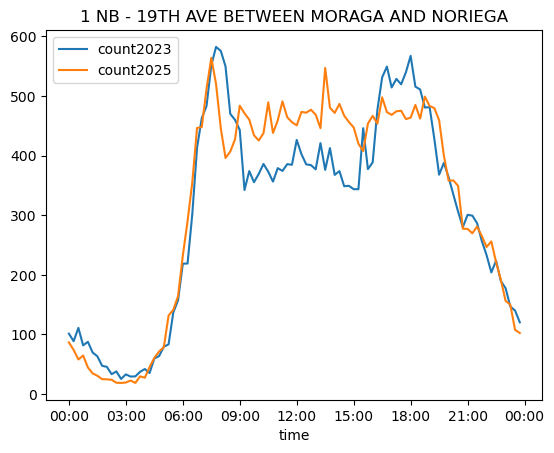

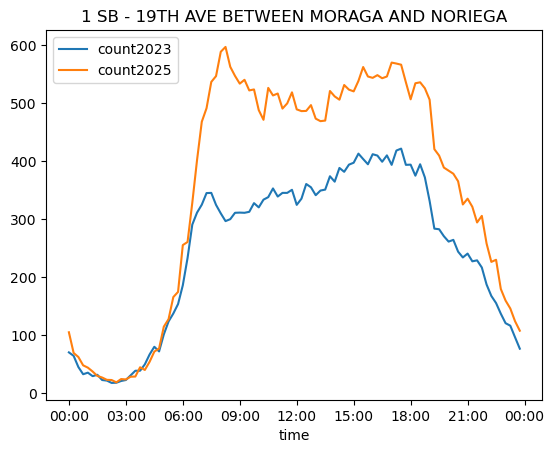

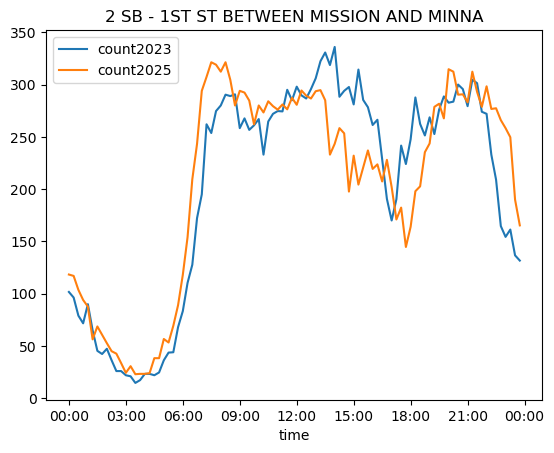

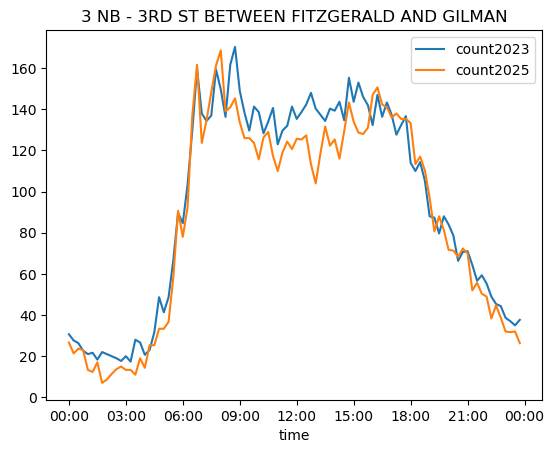

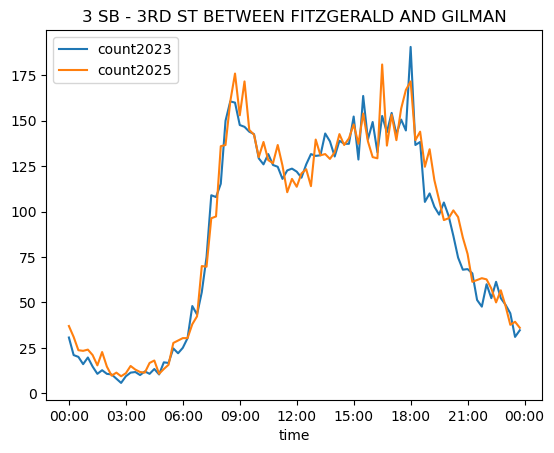

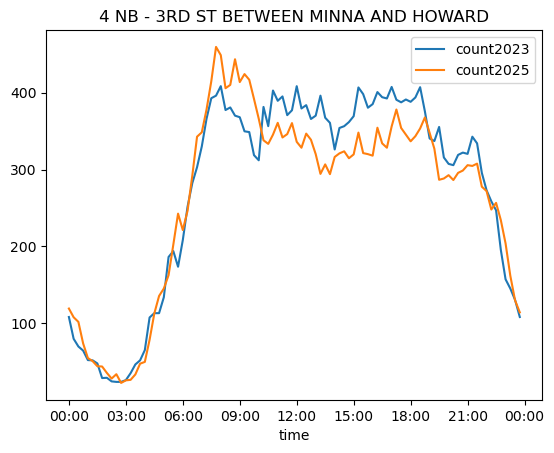

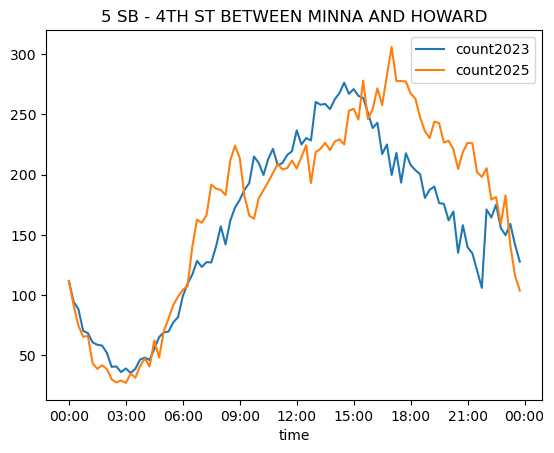

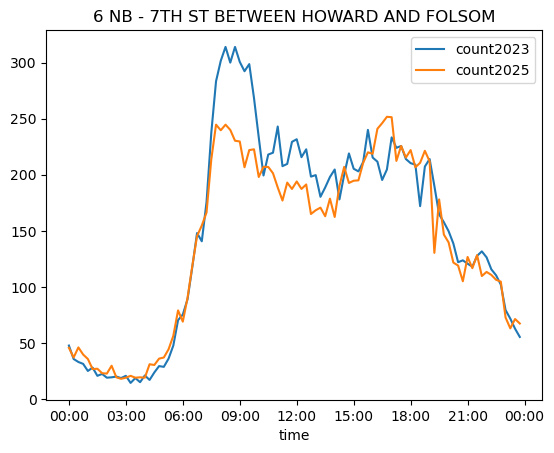

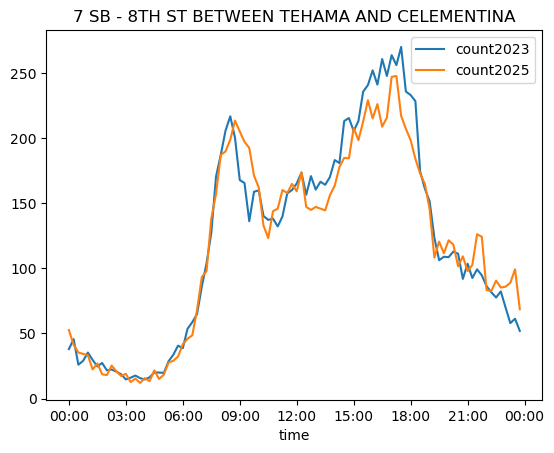

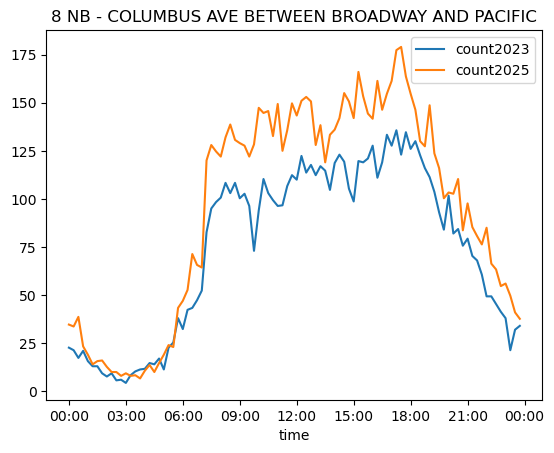

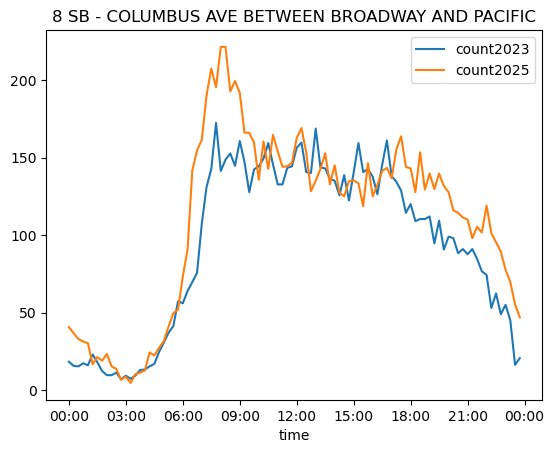

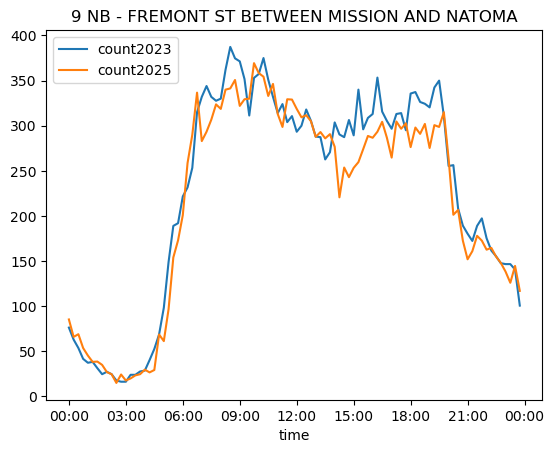

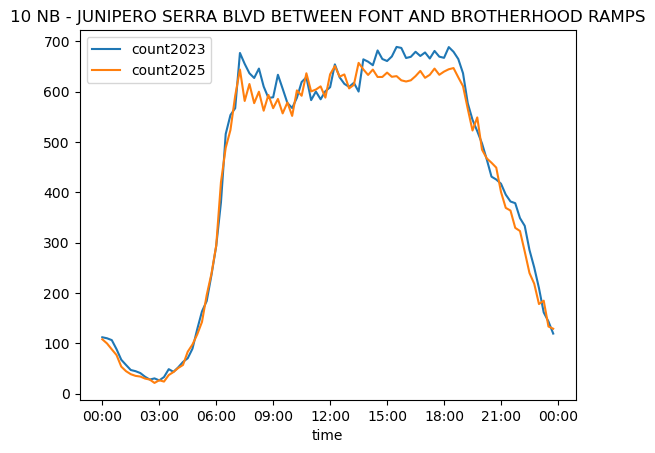

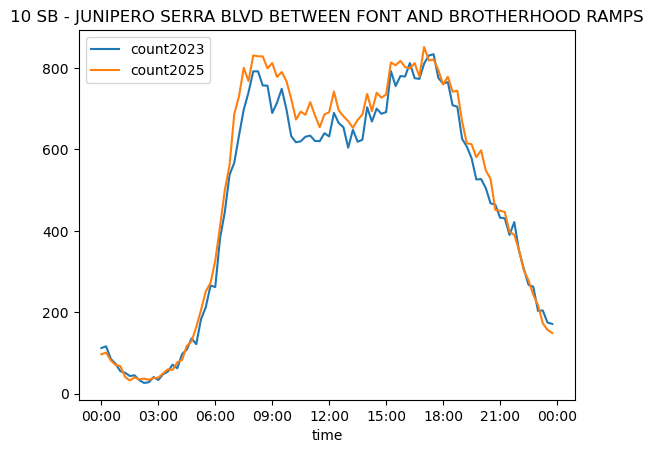

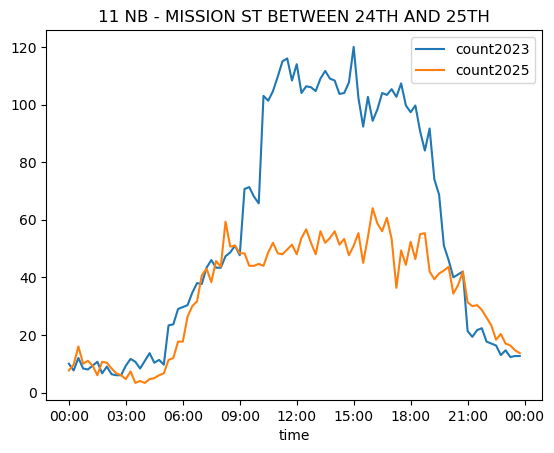

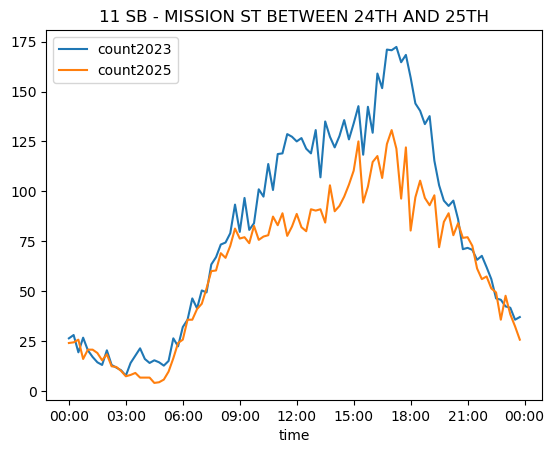

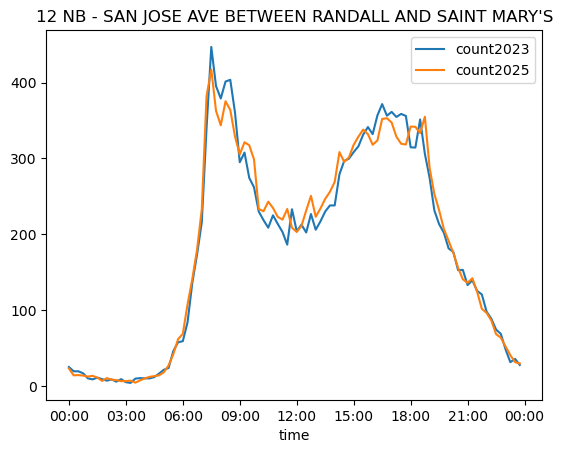

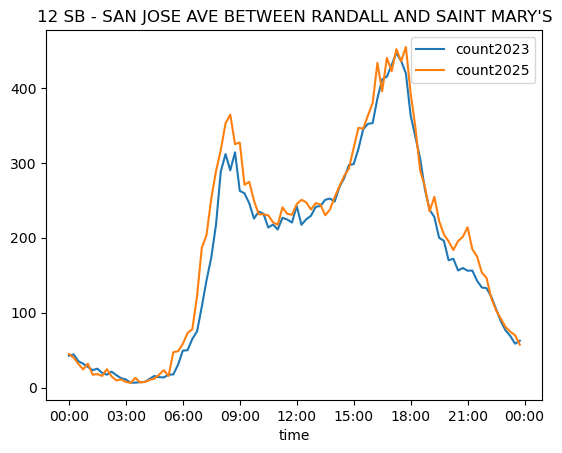

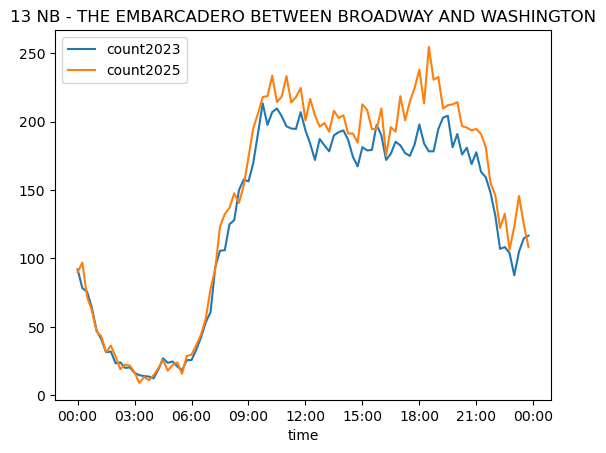

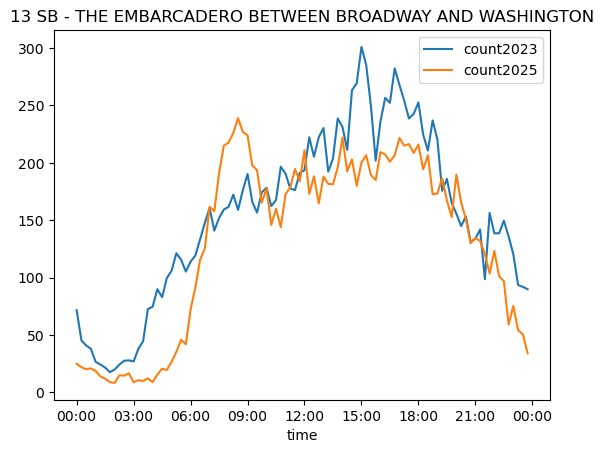

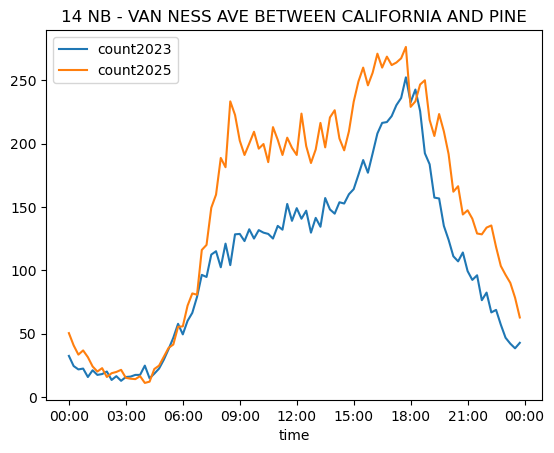

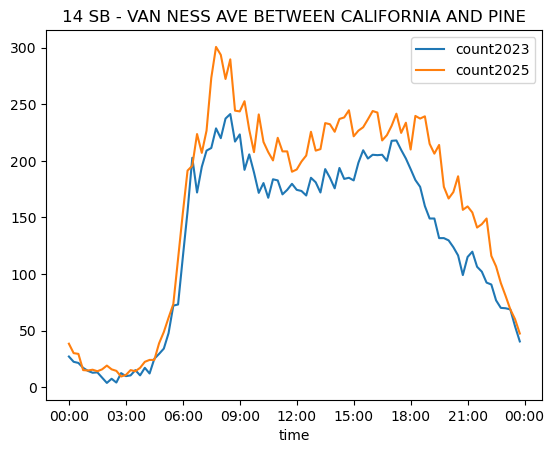

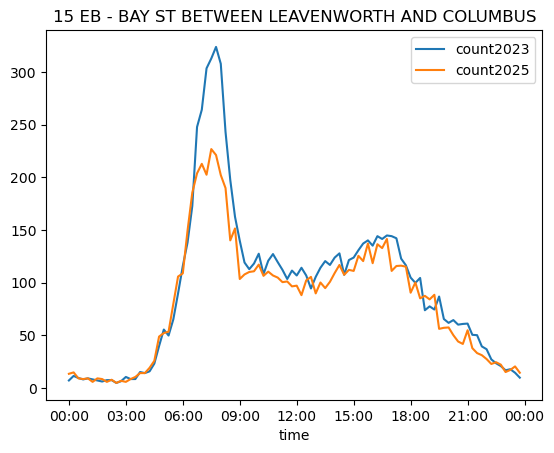

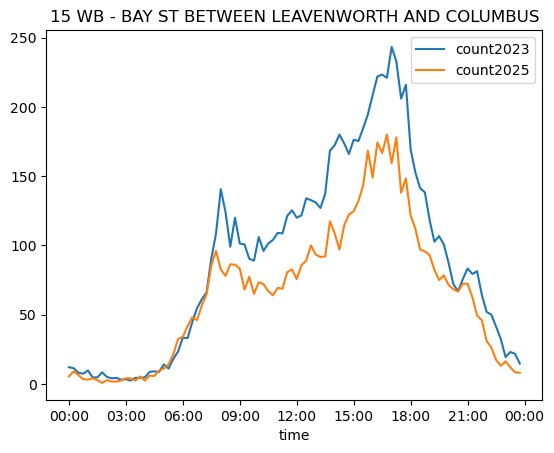

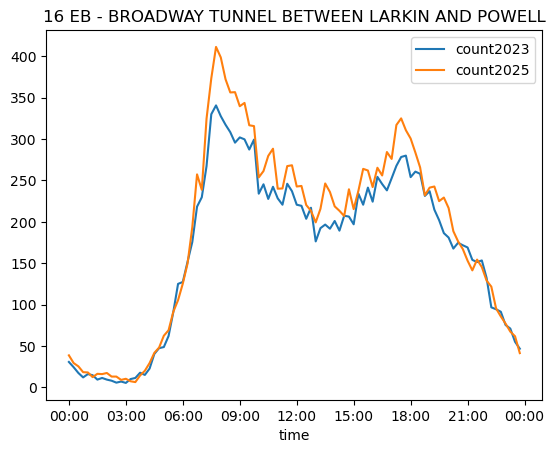

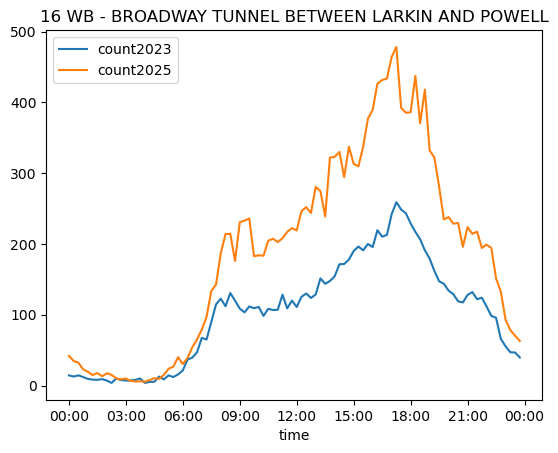

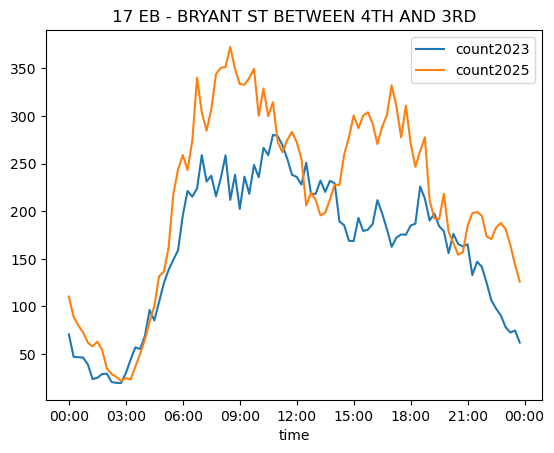

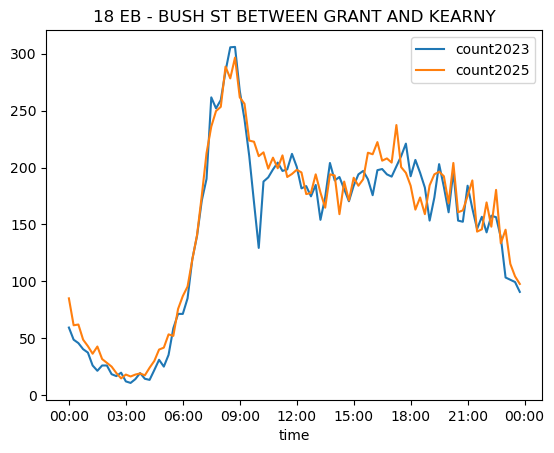

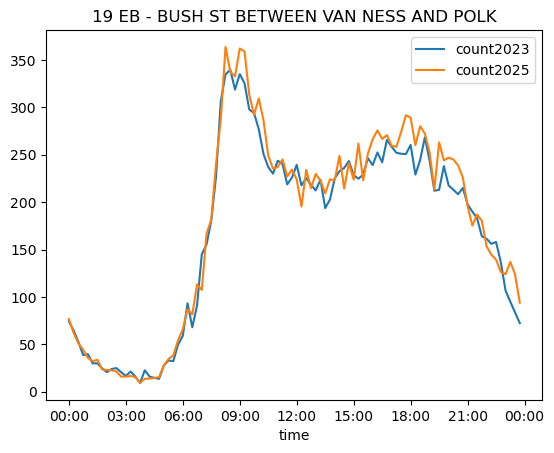

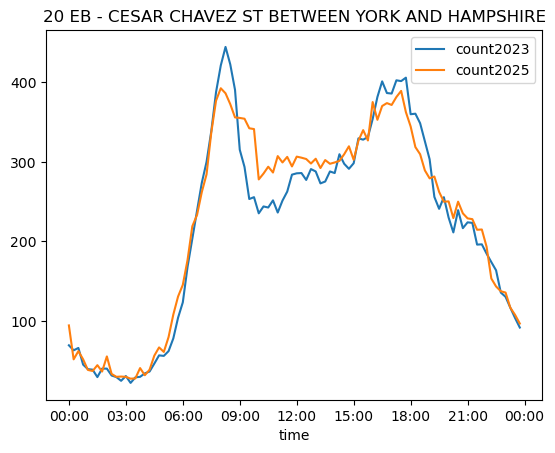

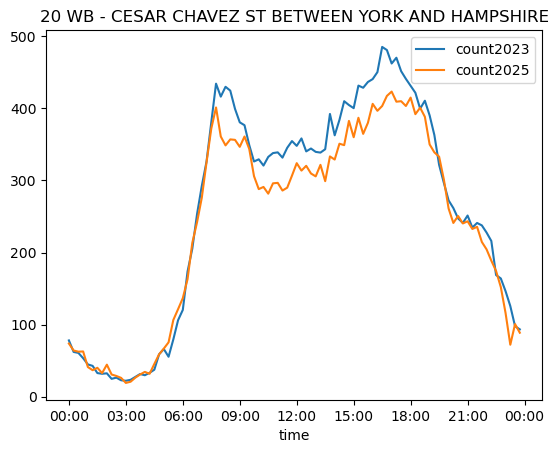

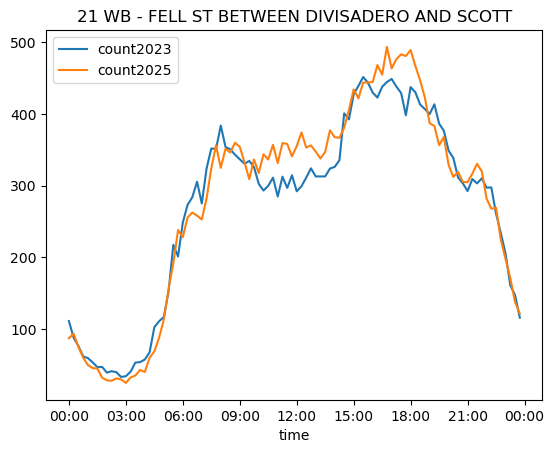

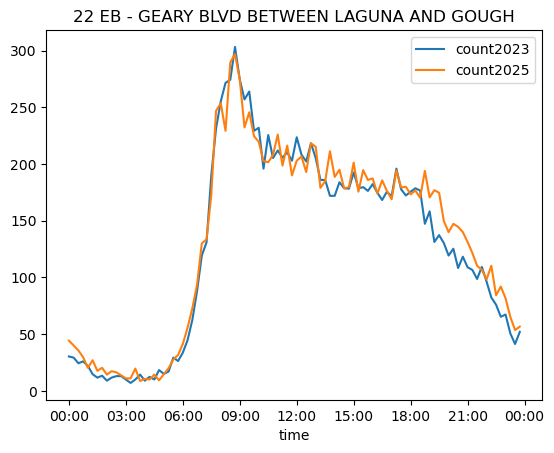

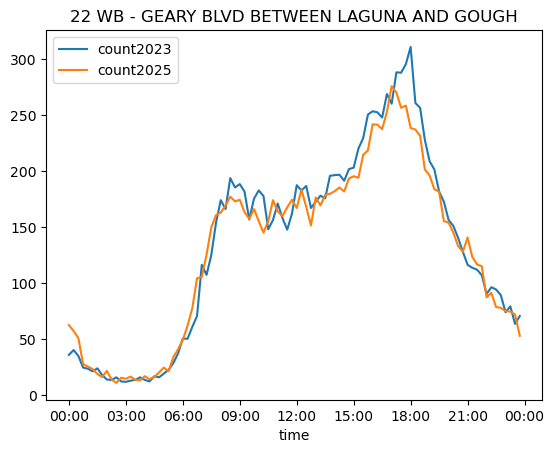

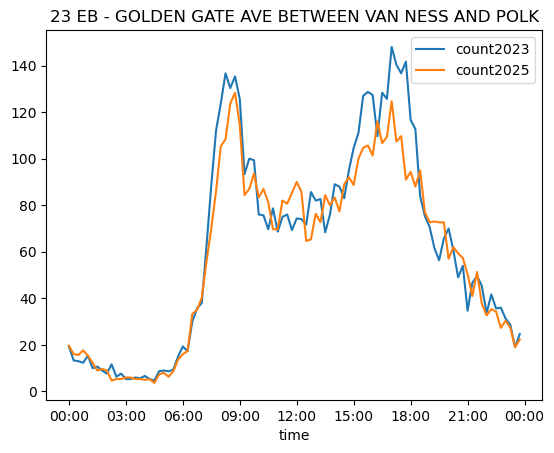

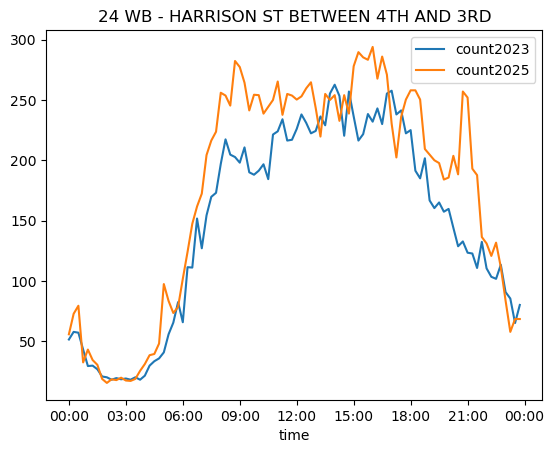

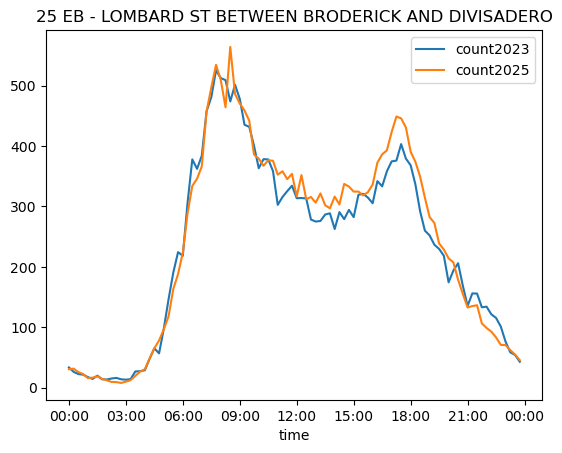

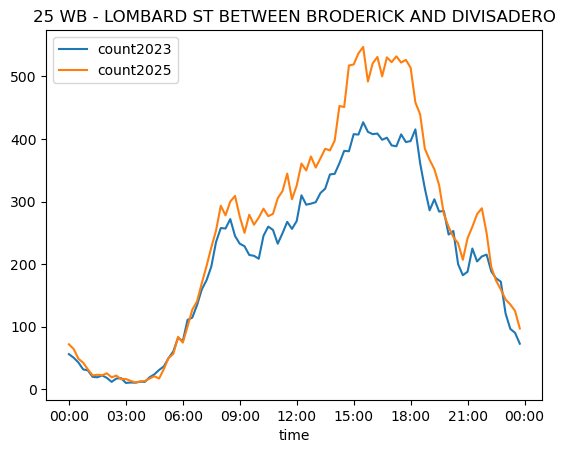

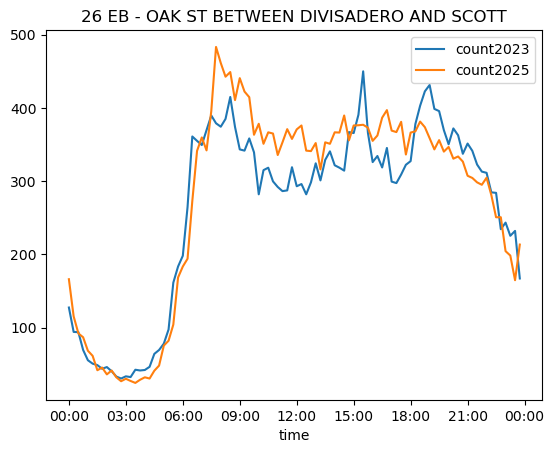

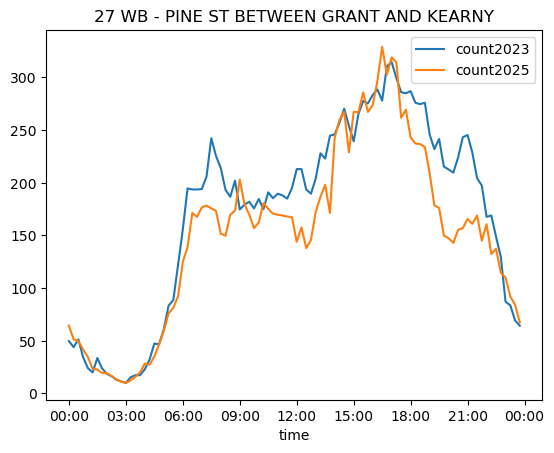

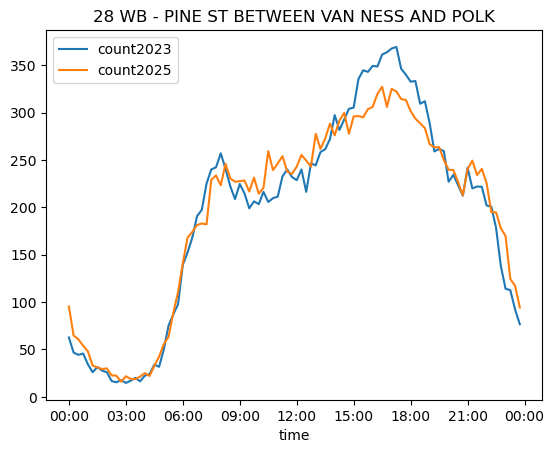

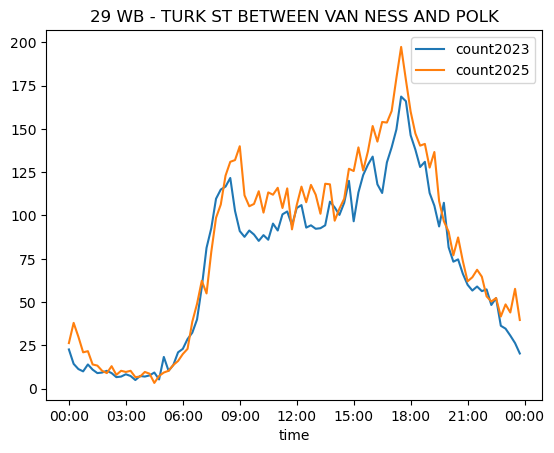

In [44]:
for (id, dir), g in aligned.groupby(['location_id','direction']):
    name = locations.loc[(id, dir), 'location_name']
    fig, ax = plt.subplots()
    ax.set_xticks(range(0,24*60*60+1,10800))
    ax.set_title('{} {} - {}'.format(id, dir, name))
    g[['time','count2023','count2025']].plot(x='time', ax=ax)

C:\Users\drew\AppData\Local\Temp\ipykernel_70228\4170331547.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


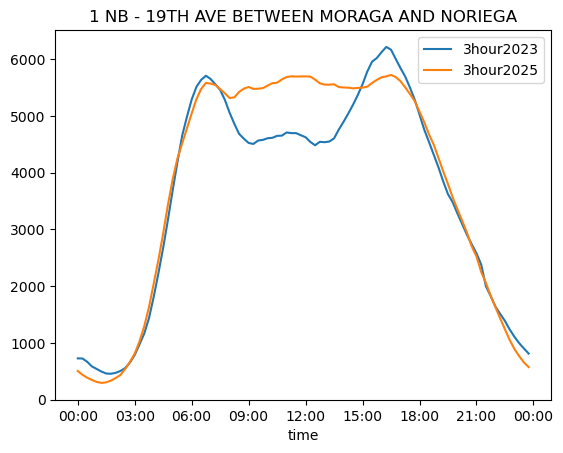

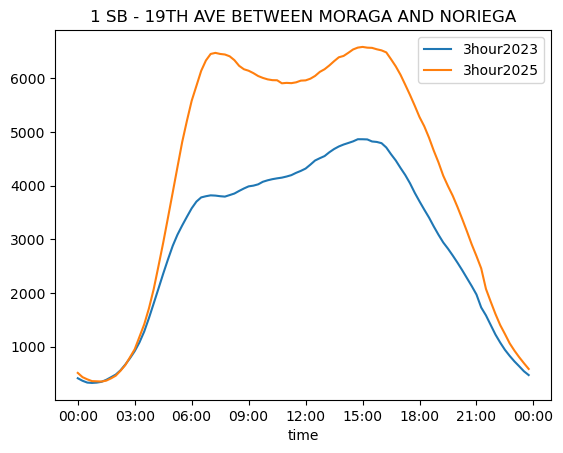

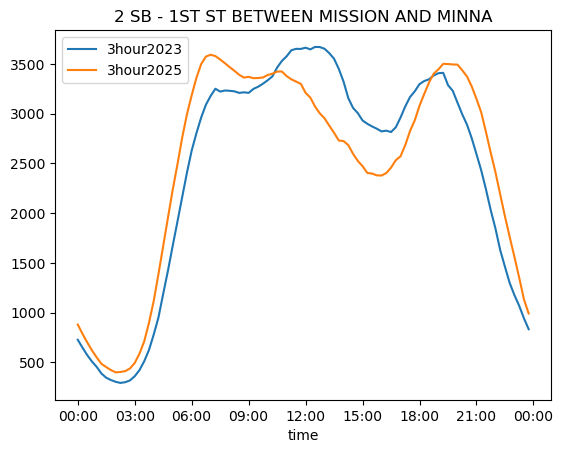

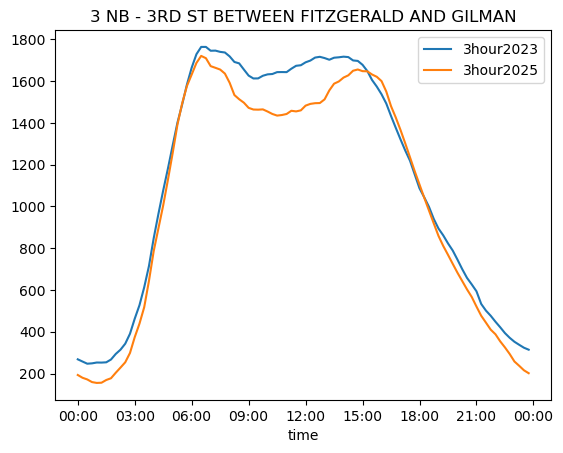

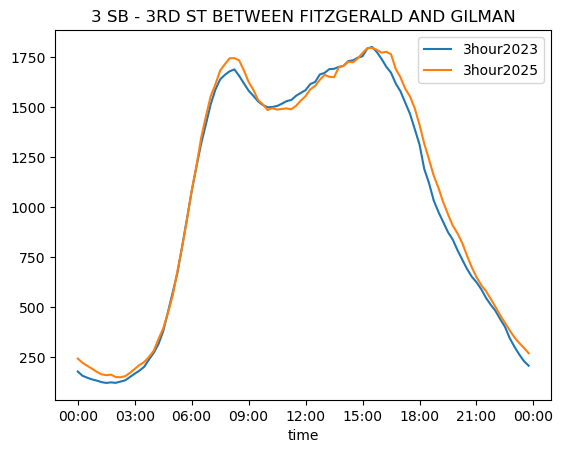

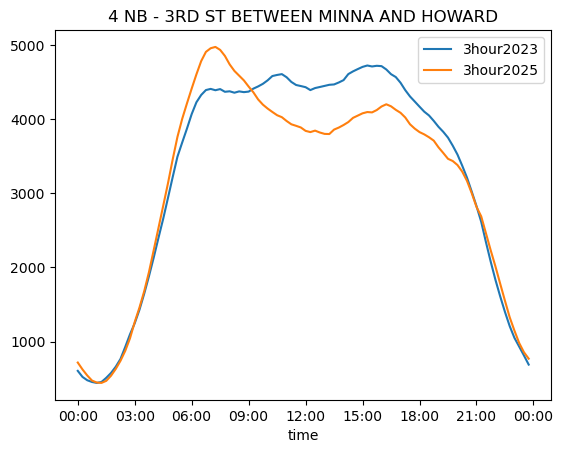

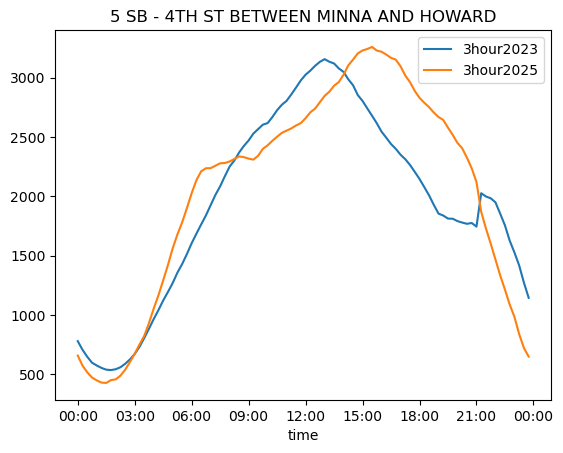

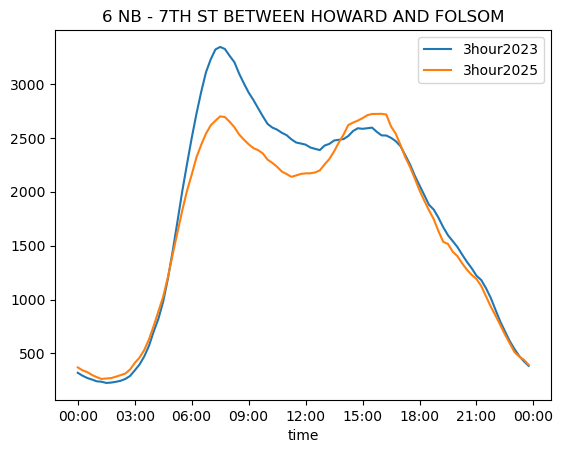

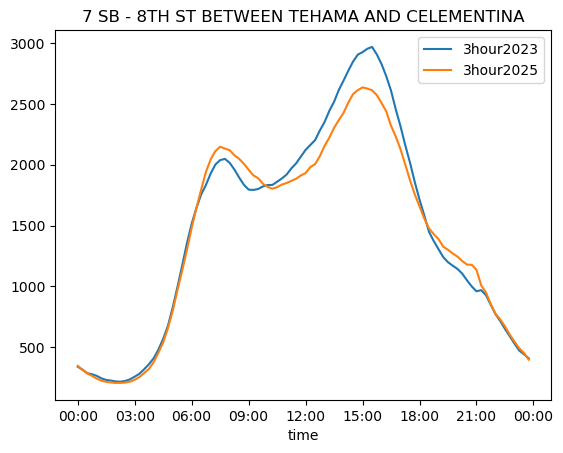

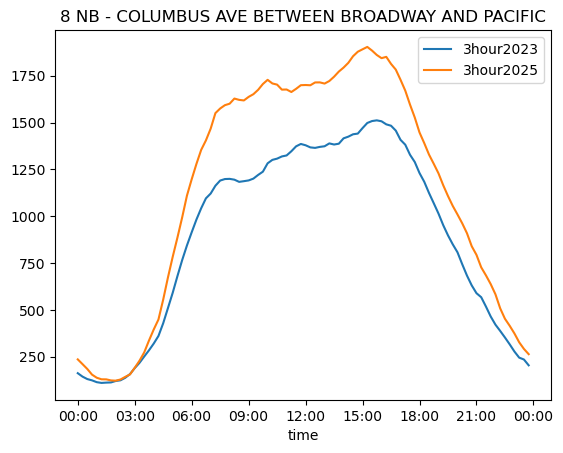

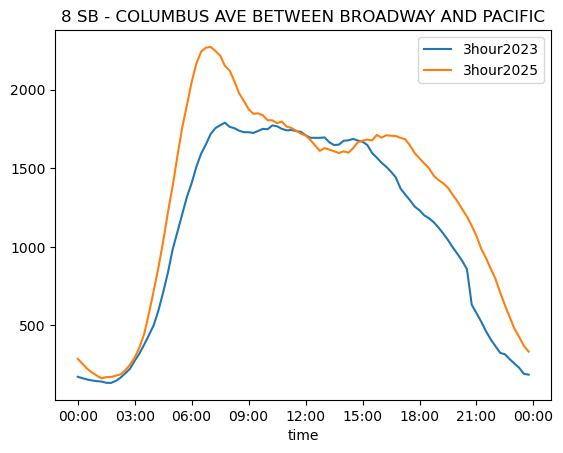

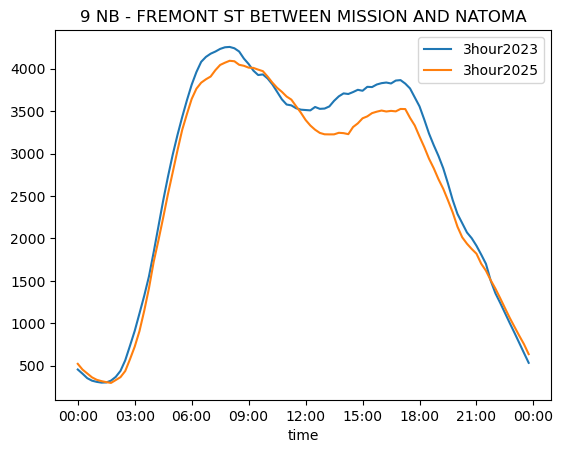

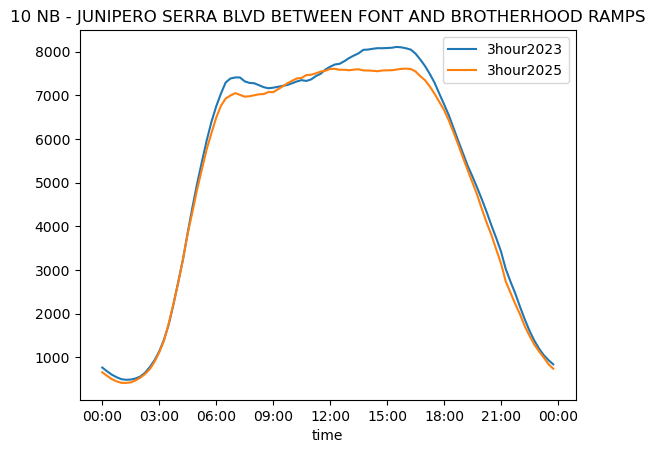

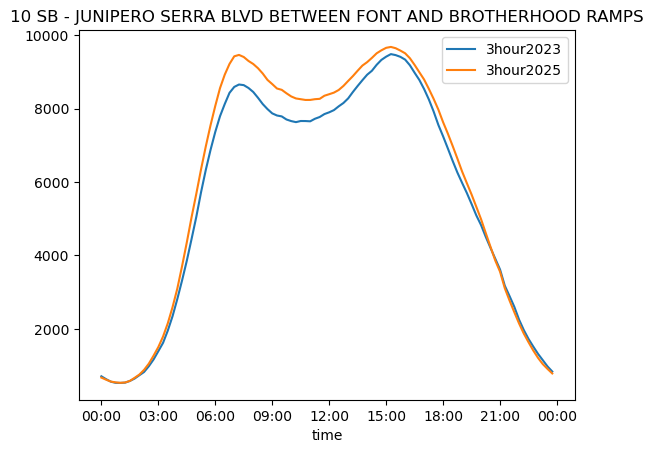

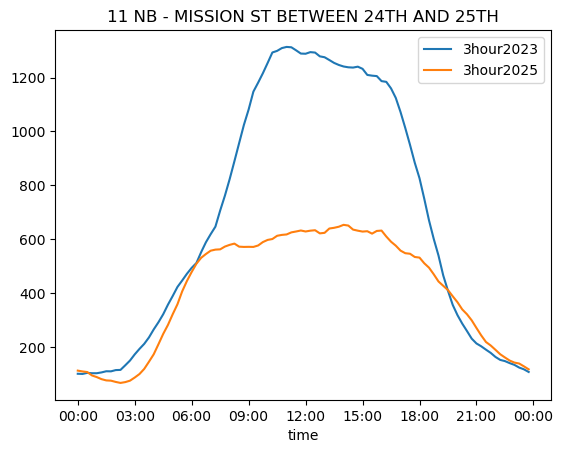

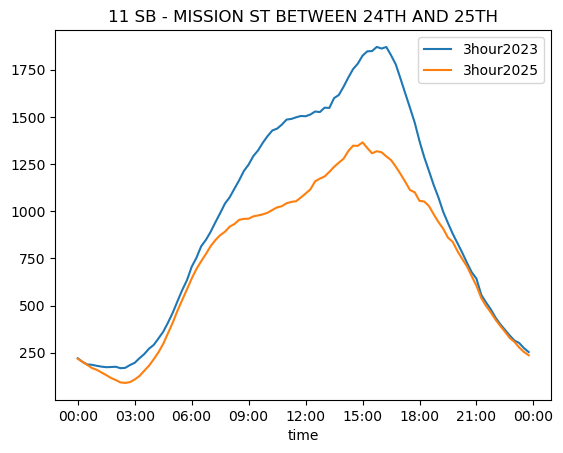

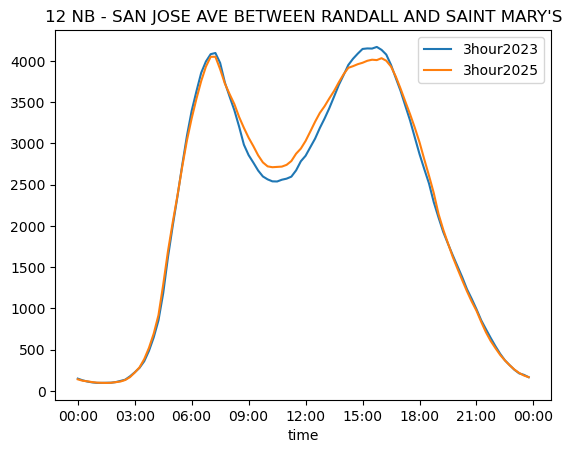

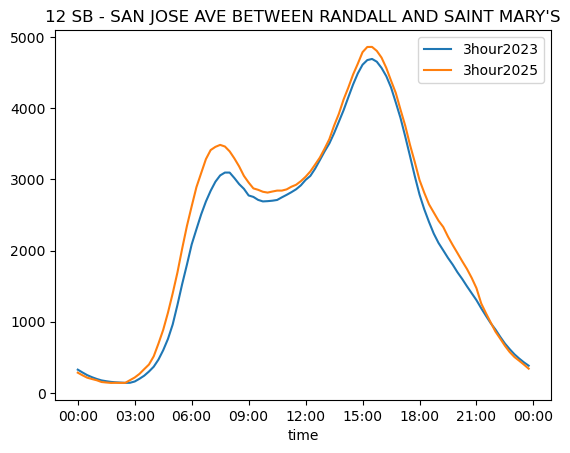

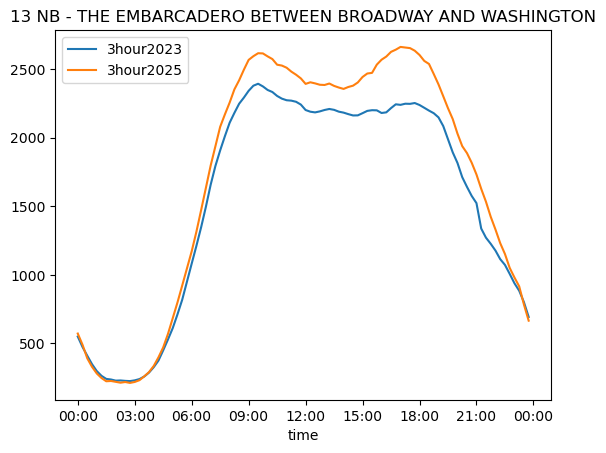

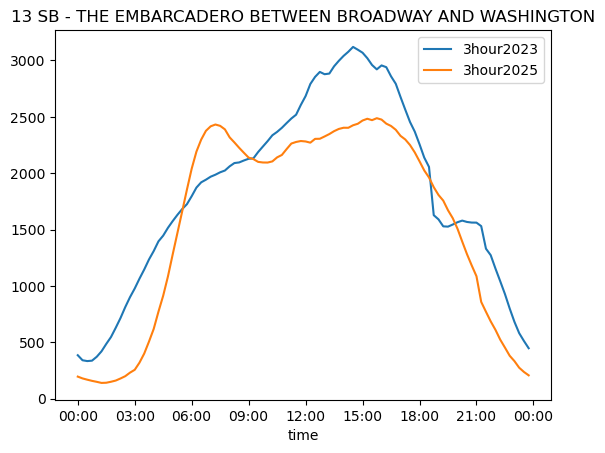

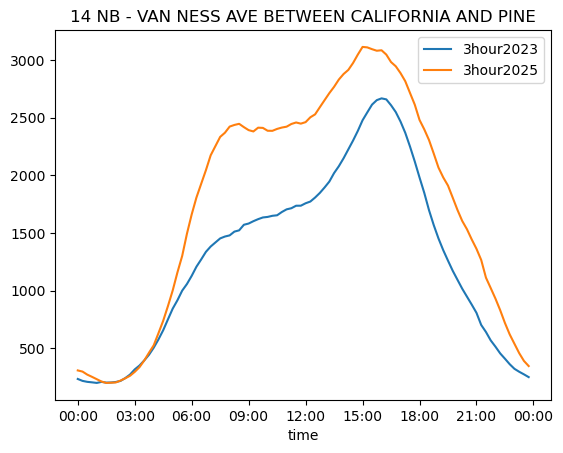

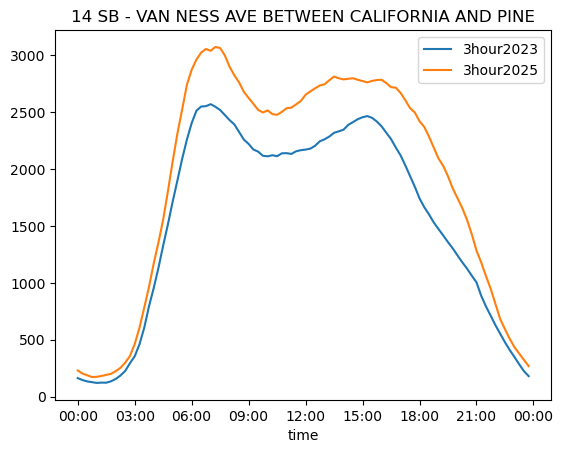

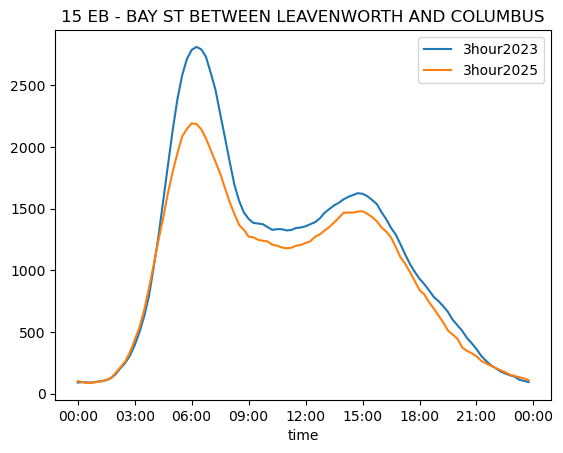

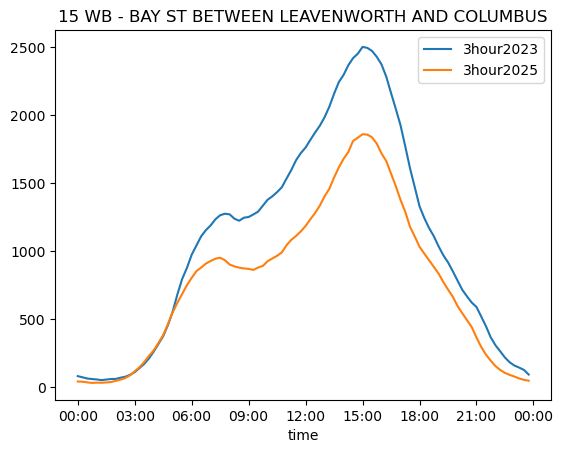

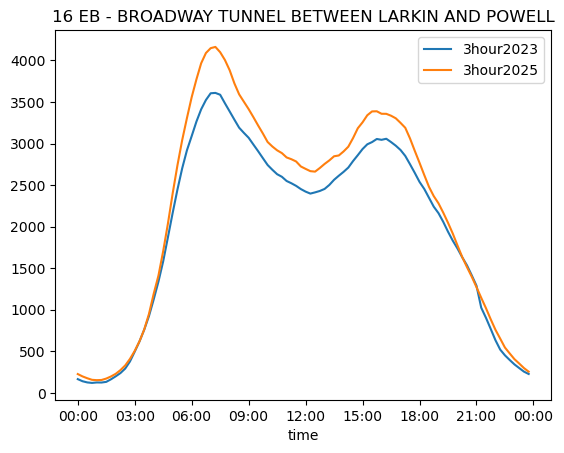

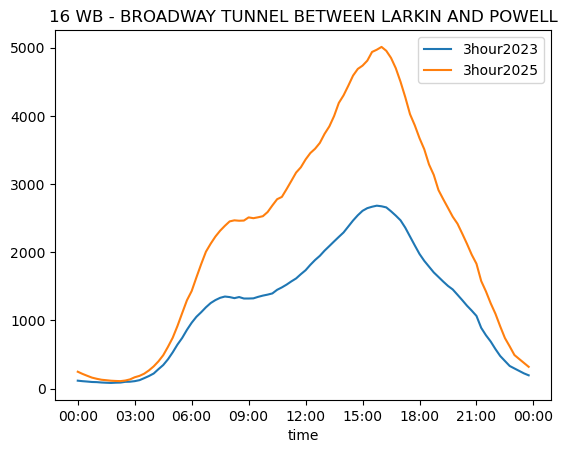

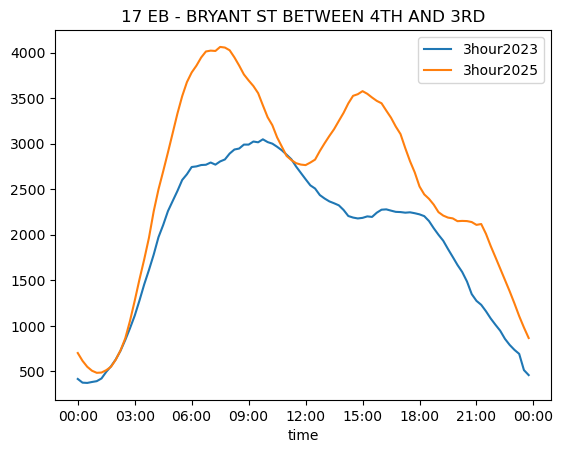

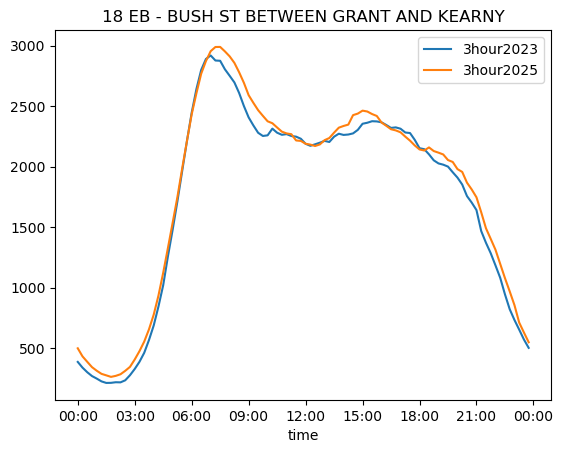

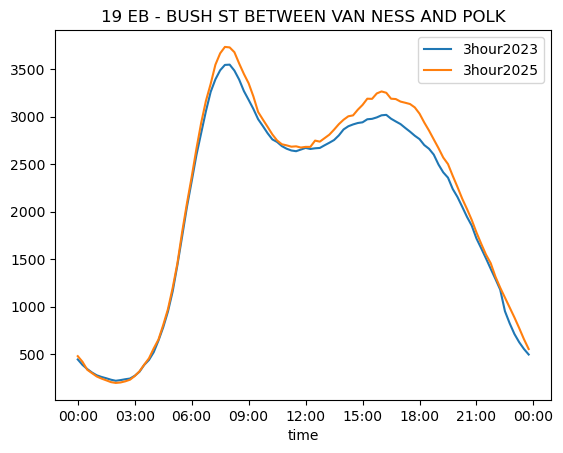

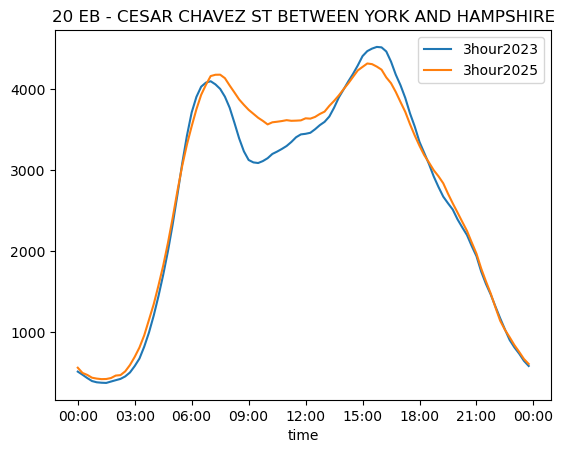

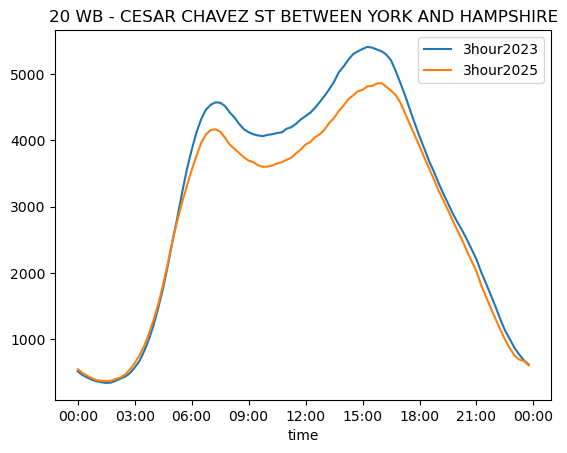

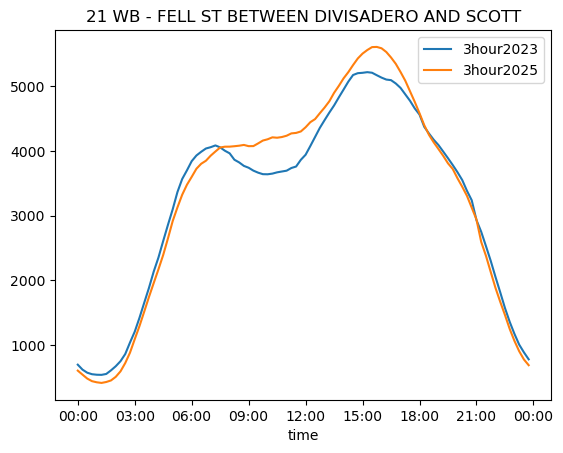

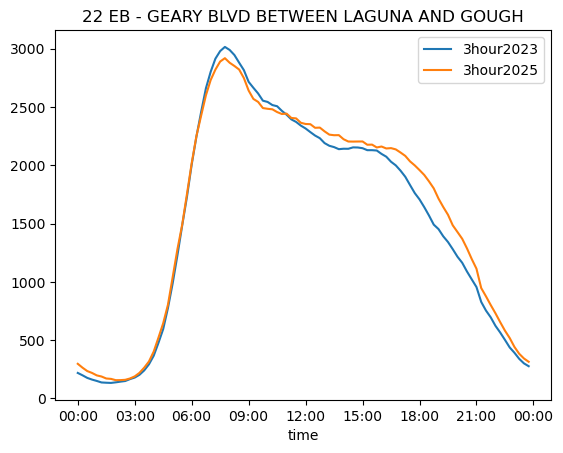

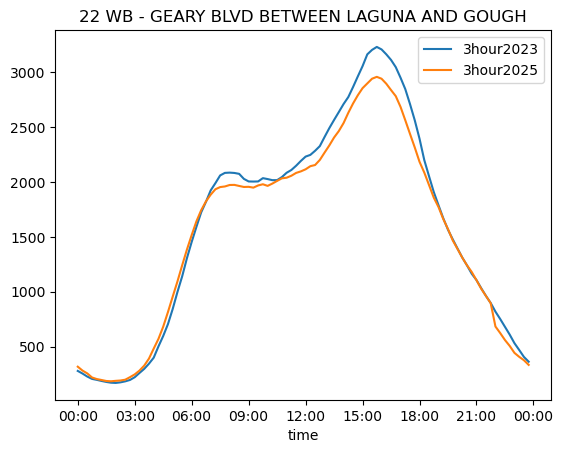

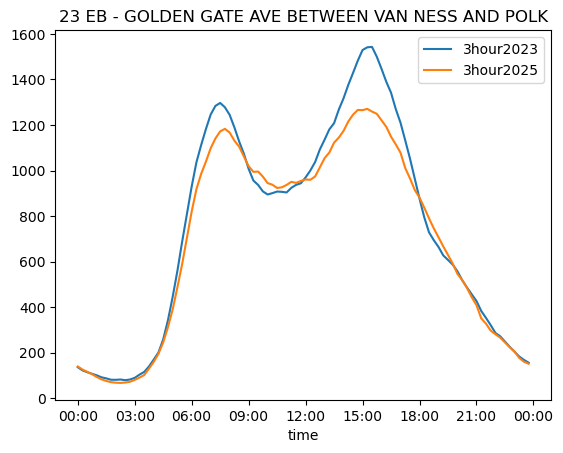

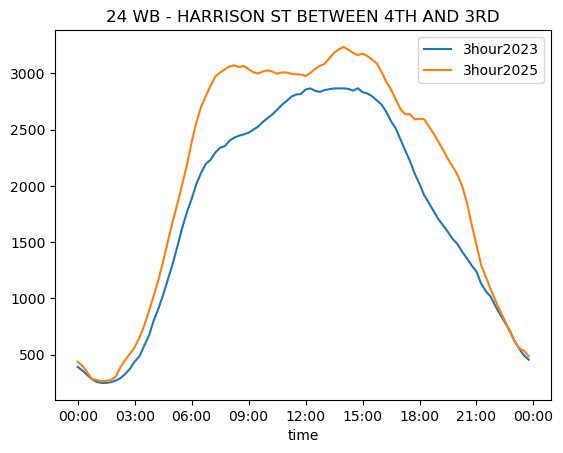

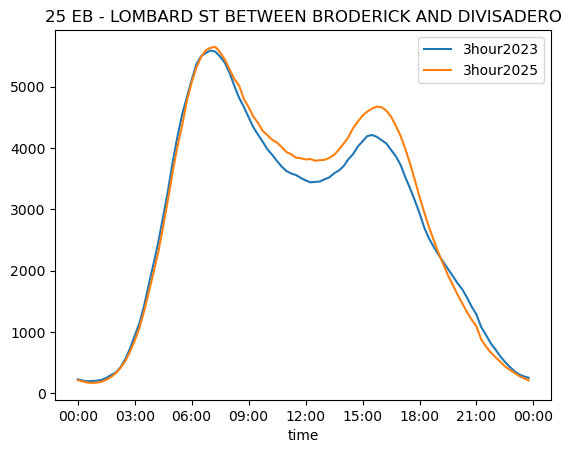

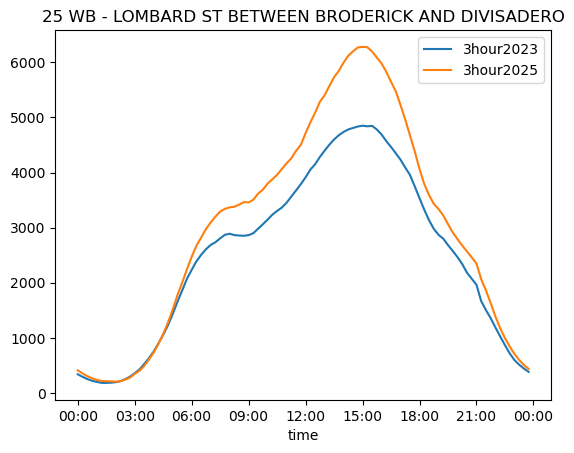

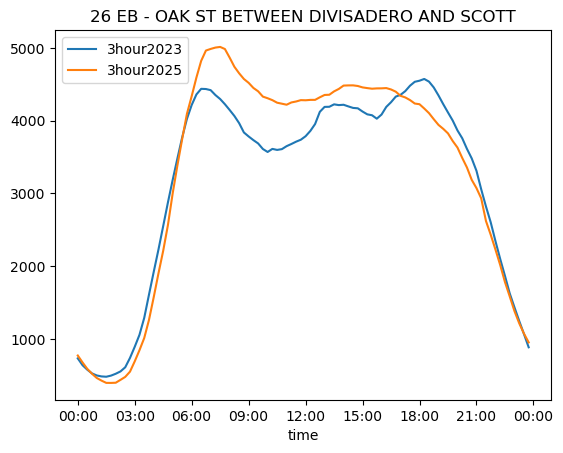

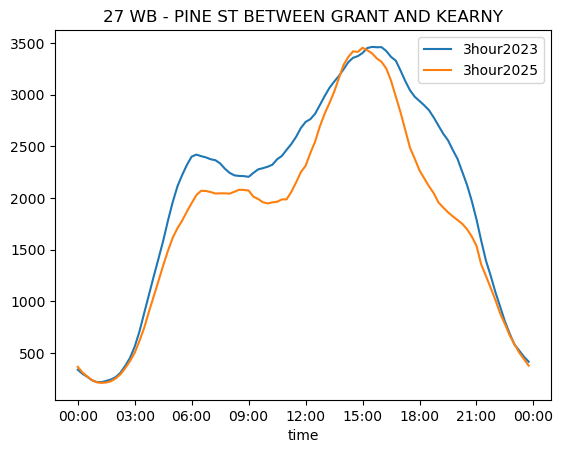

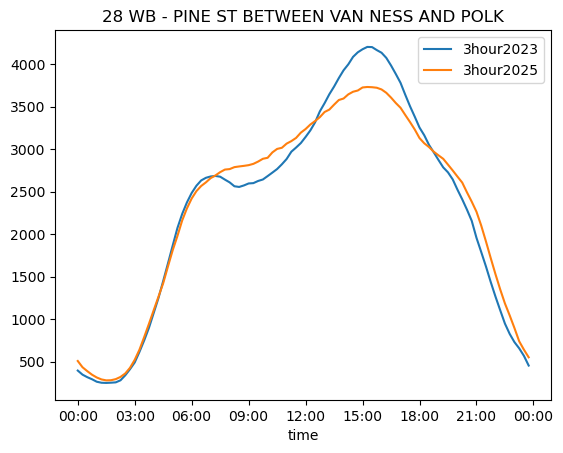

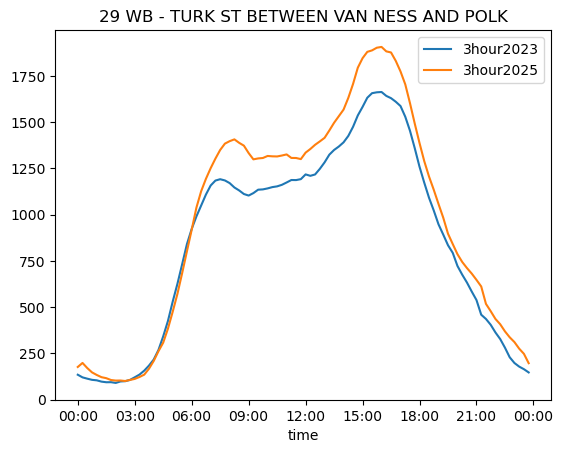

In [45]:
for (id, dir), g in aligned.groupby(['location_id','direction']):
    name = locations.loc[(id, dir), 'location_name']
    fig, ax = plt.subplots()
    ax.set_xticks(range(0,24*60*60+1,10800))
    ax.set_title('{} {} - {}'.format(id, dir, name))
    g[['time','3hour2023','3hour2025']].plot(x='time', ax=ax)
    
    #plt.savefig(OUTDIR / 'figs/15min/{}{}-{} (15 min).jpg'.format(id, dir, name))